<a href="https://www.kaggle.com/code/michaelworkineh/breast-cancer-detection?scriptVersionId=316077436" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Breast Cancer Detection Using YoloV12

## Input File Check

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Install and Import Ultralytics

In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of mkl-fft to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-random to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-umath to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of tbb4py to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Setting Up YOLO-V12 Model for Training

In [4]:
data_yaml_path='/kaggle/input/breast-cancer-yolov8/data.yaml'
model = YOLO('yolo12l.pt') 
results = model.train(
    data=str(data_yaml_path),
    epochs=50,
    batch=8,
    workers=2,
    patience=20,
    seed=42,
    project='Breast Cancer Detection',
    name='yolo12l_batch8_exp1',
    device=0,
    optimizer='AdamW',
    lr0 = 0.0005,        
    weight_decay= 0.0005,
    label_smoothing= 0.1,
    hsv_h= 0.015,
    hsv_s= 0.7,
    hsv_v= 0.4,
    degrees= 1.0,
    translate= 0.1,
    scale= 0.5,
    shear= 0.0,
    perspective= 0.0,
    flipud= 0.0,
    fliplr= 0.5,
    mosaic= 1.0,
    mixup= 0.1,
    copy_paste= 0.0 ,
)


print("\nYOLO model training complete!")
print("Trained model weights saved to:", model.trainer.best) # Path to the best performing model
print("Training results (metrics, plots) are in:", model.trainer.save_dir)

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.46 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/breast-cancer-yolov8/data.yaml, degrees=1.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo12l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        240        251       0.92        0.9      0.891      0.724
                cancer        171        182       0.98        0.8      0.866      0.697
                normal         69         69       0.86          1      0.916       0.75
Speed: 0.2ms preprocess, 22.4ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/Breast Cancer Detection/yolo12l_batch8_exp1

YOLO model training complete!
Trained model weights saved to: /kaggle/working/runs/detect/Breast Cancer Detection/yolo12l_batch8_exp1/weights/best.pt
Training results (metrics, plots) are in: /kaggle/working/runs/detect/Breast Cancer Detection/yolo12l_batch8_exp1


## Model Validation

In [5]:
new_Metrics  = model.val(data=data_yaml_path, imgsz=640, augment=True, split='val')
print('mAP50:', new_Metrics.box.map50, 'mAP50-95:', new_Metrics.box.map, 'mAP75:',new_Metrics.box.map75, 'Precision:', new_Metrics.box.ap)


Ultralytics 8.4.46 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLOv12l summary (fused): 283 layers, 26,340,614 parameters, 0 gradients, 88.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 41.8±12.3 MB/s, size: 30.5 KB)
val: Scanning /kaggle/input/breast-cancer-yolov8/valid/labels... 240 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 240/240 604.5it/s 0.4s
WARNING ⚠️ val: Cache directory /kaggle/input/breast-cancer-yolov8/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 1.0it/s 14.5s


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        240        251      0.877      0.923      0.895      0.733
                cancer        171        182      0.894      0.846       0.88      0.715
                normal         69         69      0.861          1      0.909      0.751
Speed: 2.0ms preprocess, 53.3ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
mAP50: 0.8945827318232453 mAP50-95: 0.7328714610229988 mAP75: 0.8426306460783713 Precision: [    0.71507     0.75067]


### Overall Metrics
#### mAP50–95
Mean Average Precision averaged over IoU thresholds from 0.50 to 0.95 (step 0.05). It measures overall detection accuracy and localization quality.

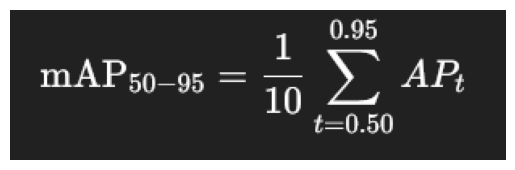

In [6]:
import cv2
img = cv2.imread('/kaggle/input/datasets/michaelworkineh/formulas/formulas/Screenshot 2025-12-23 094952.png')
plt.imshow(img)
plt.axis('off')
plt.show()

#### Precision
Fraction of predicted detections that are correct.
>“When the model says ‘I found something’, how often is it actually right?”

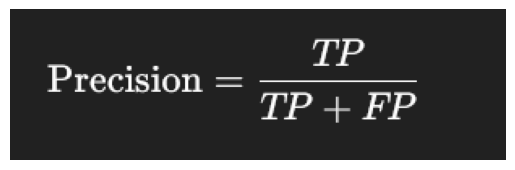

In [7]:
img = cv2.imread('/kaggle/input/datasets/michaelworkineh/formulas/formulas/Screenshot 2025-12-23 094957.png')
plt.imshow(img)
plt.axis('off')
plt.show()

#### Recall

Fraction of ground-truth objects that are successfully detected.
>“Out of everything that really exists, how much did the model actually find?”

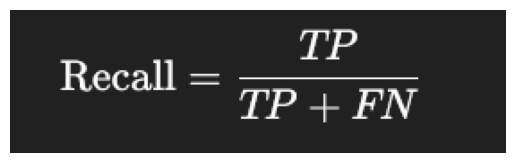

In [8]:
img = cv2.imread('/kaggle/input/datasets/michaelworkineh/formulas/formulas/Screenshot 2025-12-23 095004.png')
plt.imshow(img)
plt.axis('off')
plt.show()

#### F1-Score

Harmonic mean of Precision and Recall, balancing both.
>“How good is the model when we care about BOTH being right and not missing things?”

Harmonic mean is a type of average that is used when you want to balance rates or ratios and penalize large differences between values.

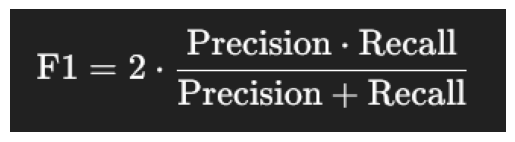

In [9]:
img = cv2.imread('/kaggle/input/datasets/michaelworkineh/formulas/formulas/Screenshot 2025-12-23 095009.png')
plt.imshow(img)
plt.axis('off')
plt.show()

#### FPS (Frames Per Second)

Number of images processed per second, measuring inference speed.
>“How many images can the model process every second?”

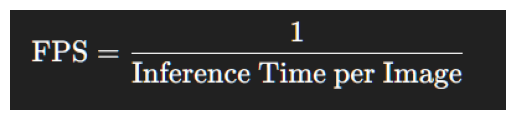

In [10]:
img = cv2.imread('/kaggle/input/datasets/michaelworkineh/formulas/formulas/Screenshot 2025-12-23 095014.png')
plt.imshow(img)
plt.axis('off')
plt.show()

In [11]:
precision = new_Metrics.box.mp
recall = new_Metrics.box.mr
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
total_time = sum(new_Metrics.speed.values())
fps = 1000 / total_time if total_time > 0 else 0

# Create overall metrics DataFrame
df_overall_metrics = pd.DataFrame([
    {'metric': 'mAP50', 'value': new_Metrics.box.map50},
    {'metric': 'mAP50-95', 'value': new_Metrics.box.map},
    {'metric': 'mAP75', 'value': new_Metrics.box.map75},
    {'metric': 'Precision', 'value': precision},
    {'metric': 'Recall', 'value': recall},
    {'metric': 'F1_Score', 'value': f1},
    {'metric': 'FPS', 'value': fps},
])
df_overall_metrics

,metric,value
0,mAP50,0.894583
1,mAP50-95,0.732871
2,mAP75,0.842631
3,Precision,0.877412
4,Recall,0.923077
5,F1_Score,0.899666
6,FPS,17.649736


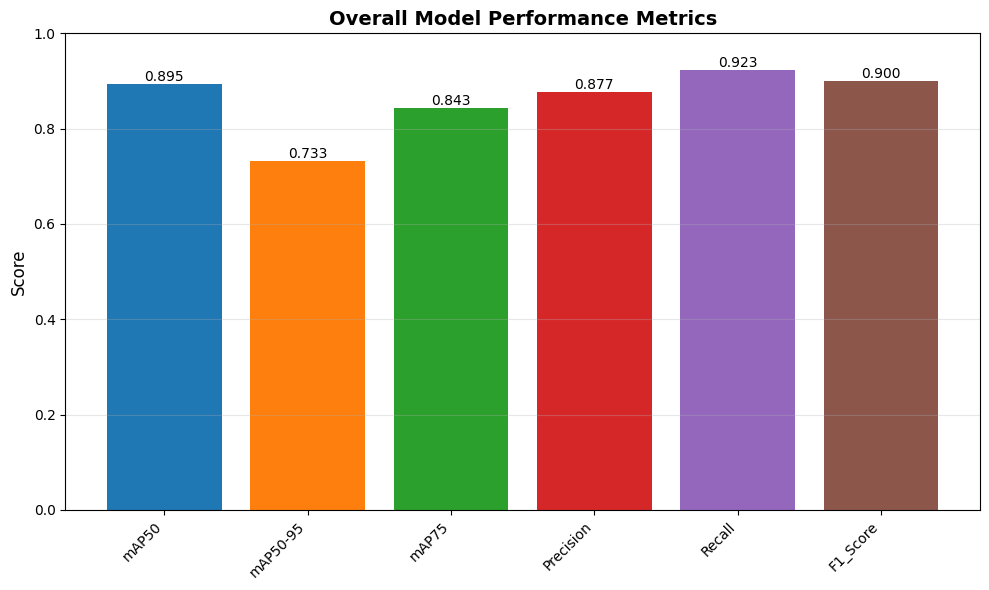

In [12]:
metrics_for_plot = df_overall_metrics[df_overall_metrics['metric'] != 'FPS']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_for_plot['metric'], metrics_for_plot['value'], 
               color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
plt.title('Overall Model Performance Metrics', fontsize=14, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Speed Metrics

In [13]:
df_speed_metrics = pd.DataFrame([
    {'stage': 'Preprocessing', 'time_ms': new_Metrics.speed['preprocess']},
    {'stage': 'Inference', 'time_ms': new_Metrics.speed['inference']},
    {'stage': 'Loss', 'time_ms': new_Metrics.speed['loss']},
    {'stage': 'Postprocessing', 'time_ms': new_Metrics.speed['postprocess']},
    {'stage': 'Total', 'time_ms': total_time},
])

df_speed_metrics.to_csv('13_speed_metrics.csv', index=False)
df_speed_metrics

,stage,time_ms
0,Preprocessing,1.970829
1,Inference,53.292070
2,Loss,0.000480
3,Postprocessing,1.394691
4,Total,56.658070


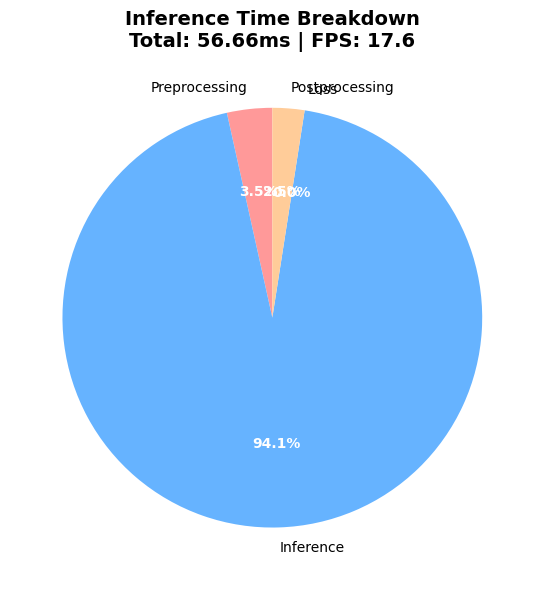

In [14]:
df_speed_plot = df_speed_metrics[df_speed_metrics['stage'] != 'Total']

plt.figure(figsize=(10, 6))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
wedges, texts, autotexts = plt.pie(df_speed_plot['time_ms'], labels=df_speed_plot['stage'], 
                                     autopct='%1.1f%%', startangle=90, colors=colors)
plt.title(f'Inference Time Breakdown\nTotal: {total_time:.2f}ms | FPS: {fps:.1f}', 
          fontsize=14, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
plt.tight_layout()
plt.show()

## Perclass Analysis

In [15]:
if new_Metrics.box.ap50 is not None and len(new_Metrics.box.ap50) > 0:
    df_per_class_metrics = pd.DataFrame({
        'class_name': [model.names[i] for i in range(len(new_Metrics.box.ap50))],
        'AP50': new_Metrics.box.ap50,
    })
    df_per_class_metrics = df_per_class_metrics.sort_values('AP50', ascending=False)
    df_per_class_metrics.to_csv('14_per_class_metrics.csv', index=False)
    df_per_class_metrics.head(10)

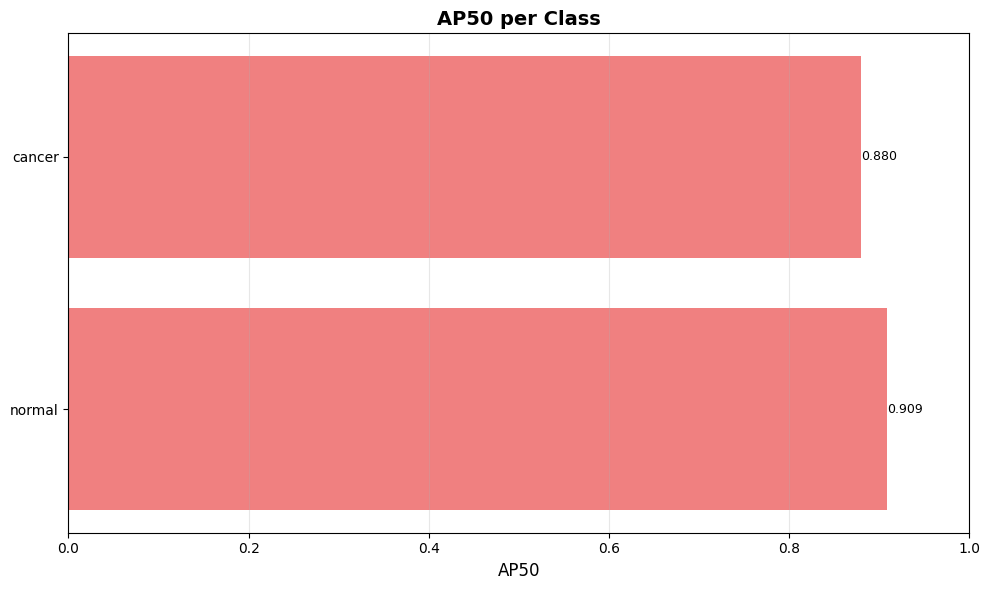

In [16]:
if new_Metrics.box.ap50 is not None and len(new_Metrics.box.ap50) > 0:
    plt.figure(figsize=(10, 6))
    bars = plt.barh(df_per_class_metrics['class_name'], df_per_class_metrics['AP50'], color='lightcoral')
    plt.title('AP50 per Class', fontsize=14, fontweight='bold')
    plt.xlabel('AP50', fontsize=12)
    plt.xlim(0, 1)
    plt.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for idx, bar in enumerate(bars):
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2.,
                 f'{width:.3f}', ha='left', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

## Performance Summary

In [17]:
if new_Metrics.box.ap50 is not None and len(new_Metrics.box.ap50) > 0:
    ap50_values = new_Metrics.box.ap50
    best_idx = np.argmax(ap50_values)
    worst_idx = np.argmin(ap50_values)
    
    df_performance_summary = pd.DataFrame([
        {'category': 'Best Performing', 'class_name': model.names[best_idx], 'AP50': ap50_values[best_idx]},
        {'category': 'Worst Performing', 'class_name': model.names[worst_idx], 'AP50': ap50_values[worst_idx]},
        {'category': 'Average', 'class_name': 'All Classes', 'AP50': ap50_values.mean()},
    ])
    
    df_performance_summary.to_csv('15_performance_summary.csv', index=False)
    df_performance_summary.head(10)

## Actually using the model
### Loading the model weights

In [18]:
 test = YOLO('/kaggle/working/runs/detect/Breast Cancer Detection/yolo12l_batch8_exp1/weights/best.pt')

### Predict an image with the model

In [19]:
testResult = test.predict('/kaggle/input/breast-cancer-yolov8/valid/images/mdb005ll_jpg.rf.0e8fda99d74c96767ae11e124b739d5e.jpg')


image 1/1 /kaggle/input/breast-cancer-yolov8/valid/images/mdb005ll_jpg.rf.0e8fda99d74c96767ae11e124b739d5e.jpg: 640x640 2 cancers, 30.0ms
Speed: 1.7ms preprocess, 30.0ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


### Plot Model's Prediction

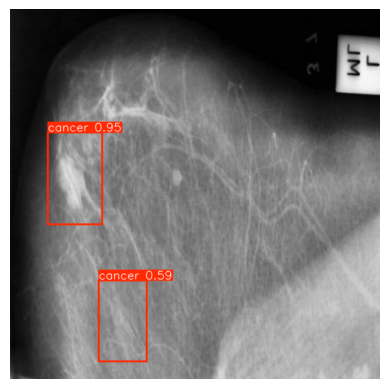

In [20]:
img = testResult[0].plot()
plt.imshow(img)
plt.axis('off')
plt.show()

### Result Analysis
#### Result Summary

In [21]:
results_data = []
for idx, result in enumerate(testResult):
    results_data.append({
        'result_id': idx,
        'image_path': result.path,
        'image_width': result.orig_shape[1],
        'image_height': result.orig_shape[0],
        'num_detections': len(result.boxes) if result.boxes else 0,
        'preprocess_ms': result.speed['preprocess'],
        'inference_ms': result.speed['inference'],
        'postprocess_ms': result.speed['postprocess'],
        'total_ms': sum(result.speed.values()),
    })

df_results_summary = pd.DataFrame(results_data)
df_results_summary.to_csv('01_results_summary.csv', index=False)
print("Saved: 01_results_summary.csv")
df_results_summary

Saved: 01_results_summary.csv


,result_id,image_path,image_width,image_height,num_detections,preprocess_ms,inference_ms,postprocess_ms,total_ms
0,0,/kaggle/input/breast-cancer-yolov8/valid/image...,640,640,2,1.70145,30.03737,1.482424,33.221244


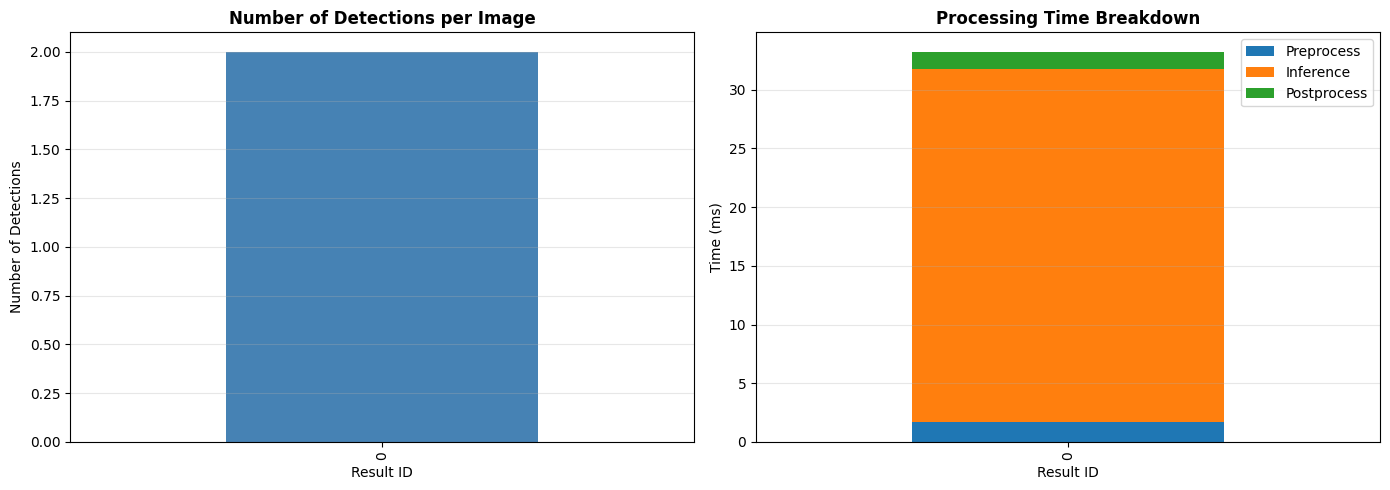

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Number of detections per image
df_results_summary.plot(x='result_id', y='num_detections', kind='bar', ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('Number of Detections per Image', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Result ID')
axes[0].set_ylabel('Number of Detections')
axes[0].grid(axis='y', alpha=0.3)

# Processing time breakdown
df_results_summary[['preprocess_ms', 'inference_ms', 'postprocess_ms']].plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Processing Time Breakdown', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Result ID')
axes[1].set_ylabel('Time (ms)')
axes[1].legend(['Preprocess', 'Inference', 'Postprocess'])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()